In [49]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt
import anndata
import sys
sys.path.append('/home/lytq/Spatial-Transcriptomics-Benchmark/utils')
from sdmbench import compute_ARI, compute_NMI, compute_CHAOS, compute_PAS, compute_ASW, compute_HOM, compute_COM

import time
import psutil
import tracemalloc

from SpaceFlow.SpaceFlow import SpaceFlow

def evaluate_clustering(adata: sc.AnnData, df_meta, time_taken: float, memory_used: float, output_dir: str) -> dict:
    """Evaluate clustering using sdmbench"""
    gt_key = 'ground_truth'
    pred_key = 'pred'
    adata.obs['ground_truth'] = df_meta['fine_annot_type'].values
    adata = adata[~pd.isnull(adata.obs['ground_truth'])]
    
    results = {
        "ARI": compute_ARI(adata, gt_key, pred_key),
        "AMI": compute_NMI(adata, gt_key, pred_key),
        "Homogeneity": compute_HOM(adata, gt_key, pred_key),
        "Completeness": compute_COM(adata, gt_key, pred_key),
        "ASW": compute_ASW(adata, pred_key),
        "CHAOS": compute_CHAOS(adata, pred_key),
        "PAS": compute_PAS(adata, pred_key),
        "Time": time_taken,
        "Memory": memory_used
    }
    
    df_results = pd.DataFrame([results])
    df_results.to_csv(os.path.join(output_dir, "metrics.csv"), index=False)
    return results

BASE_PATH = Path('/home/lytq/Spatial-Transcriptomics-Benchmark/data/BRCA1')
output_path = Path('/home/lytq/Spatial-Transcriptomics-Benchmark/Results/')

sample = 'V1_Human_Breast_Cancer_Block_A_Section_1'

In [50]:
def set_seed(seed):
    np.random.seed(seed)
    import random
    random.seed(seed)
    import torch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEEDS = [42, 123, 456, 789, 2024]

In [51]:
seed = SEEDS[4] 
set_seed(seed)

dir_input = Path(f'{BASE_PATH}/{sample}/')
dir_output = Path(f'{output_path}/{seed}/BRCA1/SpaceFlow/')
dir_output.mkdir(parents=True, exist_ok=True)

n_clusters = 20

start_time = time.time()
tracemalloc.start()

adata = sc.read_visium(dir_input)
adata.var_names_make_unique()
gt_df = pd.read_csv(dir_input / 'metadata.tsv', sep='\t')
adata.obs['layer_guess'] = gt_df['fine_annot_type'].values

sc.pp.filter_genes(adata, min_cells=3)

sf = SpaceFlow.SpaceFlow(adata=adata)
sf.preprocessing_data(n_top_genes=3000)

sf.train(
    spatial_regularization_strength=0.1,
    z_dim=50,
    lr=1e-3,
    epochs=1000,
    max_patience=50,
    min_stop=100,
    random_seed=seed,
    gpu=6,
    regularization_acceleration=True,
    edge_subset_sz=1000000,
    embedding_save_filepath=os.path.join(dir_output, "low_dim_data.csv"),
)

/home/lytq/.conda/envs/spaceflow_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lytq/.conda/envs/spaceflow_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Epoch 2/1000, Loss: 1.4406033754348755
Epoch 12/1000, Loss: 1.3697035312652588
Epoch 22/1000, Loss: 1.1597872972488403
Epoch 32/1000, Loss: 0.8028607964515686
Epoch 42/1000, Loss: 0.48512834310531616
Epoch 52/1000, Loss: 0.4142162799835205
Epoch 62/1000, Loss: 0.22976729273796082
Epoch 72/1000, Loss: 0.16168250143527985
Epoch 82/1000, Loss: 0.14469251036643982
Epoch 92/1000, Loss: 0.10678809881210327
Epoch 102/1000, Loss: 0.08967408537864685
Epoch 112/1000, Loss: 0.074827641248703
Epoch 122/1000, Loss: 0.07707124948501587
Epoch 132/1000, Loss: 0.0646912008523941
Epoch 142/1000, Loss: 0.06262631714344025
Epoch 152/1000, Loss: 0.06792620569467545
Epoch 162/1000, Loss: 0.06421096622943878
Epoch 172/1000, Loss: 0.05352584645152092
Epoch 182/1000, Loss: 0.05829876288771629
Epoch 192/1000, Loss: 0.0515744686126709
Epoch 202/1000, Loss: 0.05248881131410599
Epoch 212/1000, Loss: 0.054606348276138306
Epoch 222/1000, Loss: 0.05408649891614914
Epoch 232/1000, Loss: 0.047573547810316086
Epoch 242/

array([[ 2.2457964 , -0.31150794, -0.14729798, ...,  3.8877718 ,
         2.9356437 , -0.18524857],
       [ 0.8026125 , -0.19750868,  2.052797  , ...,  3.243614  ,
         1.4272708 , -0.22850351],
       [ 1.7072175 , -0.28797242, -0.3237566 , ...,  3.683745  ,
         1.8733313 , -0.05983067],
       ...,
       [ 0.41675586, -0.18402648,  2.5771644 , ...,  2.9093175 ,
         1.3589587 , -0.25647762],
       [ 1.3559723 , -0.2303129 , -0.0441035 , ...,  3.0404344 ,
         0.61933315, -0.02209007],
       [ 1.1014816 , -0.43336487,  1.5621853 , ...,  3.3284698 ,
        -0.12525542, -0.16734356]], dtype=float32)

In [52]:
adata.obsm['SpaceFlow'] = sf.embedding

In [53]:
adata.obsm['SpaceFlow']

array([[ 2.2457964 , -0.31150794, -0.14729798, ...,  3.8877718 ,
         2.9356437 , -0.18524857],
       [ 0.8026125 , -0.19750868,  2.052797  , ...,  3.243614  ,
         1.4272708 , -0.22850351],
       [ 1.7072175 , -0.28797242, -0.3237566 , ...,  3.683745  ,
         1.8733313 , -0.05983067],
       ...,
       [ 0.41675586, -0.18402648,  2.5771644 , ...,  2.9093175 ,
         1.3589587 , -0.25647762],
       [ 1.3559723 , -0.2303129 , -0.0441035 , ...,  3.0404344 ,
         0.61933315, -0.02209007],
       [ 1.1014816 , -0.43336487,  1.5621853 , ...,  3.3284698 ,
        -0.12525542, -0.16734356]], dtype=float32)

In [54]:
embedding = anndata.AnnData(sf.embedding)
sc.pp.neighbors(embedding, n_neighbors=50, use_rep='X')

for res in sorted(list(np.arange(0.2, 2.5, 0.1)), reverse=True):
    sc.tl.leiden(embedding, resolution=res)
    
    if len(pd.DataFrame(embedding.obs['leiden']).leiden.unique()) == n_clusters:
        print(f"Resolution: {res}")
        break

sf.segmentation(domain_label_save_filepath=os.path.join(dir_output, "domain_labels.csv"),
                n_neighbors=50,
                resolution=res)

sc.pp.neighbors(adata, n_neighbors=50)
sc.tl.umap(adata)

pred = pd.read_csv(os.path.join(dir_output, "domain_labels.csv"), header=None)
adata.obs['pred'] = pred.values
adata.obs["pred"] = adata.obs["pred"].astype("category")  # Convert to categorical

end_time = time.time()
time_taken = end_time - start_time
current, peak = tracemalloc.get_traced_memory()
memory_used = peak / (1024 ** 2)
tracemalloc.stop()

metrics = evaluate_clustering(adata, gt_df, time_taken, memory_used, dir_output)

Resolution: 1.4000000000000004
Performing domain segmentation
Segmentation complete, domain labels of cells or spots saved at /home/lytq/Spatial-Transcriptomics-Benchmark/Results/2024/BRCA1/SpaceFlow/domain_labels.csv !


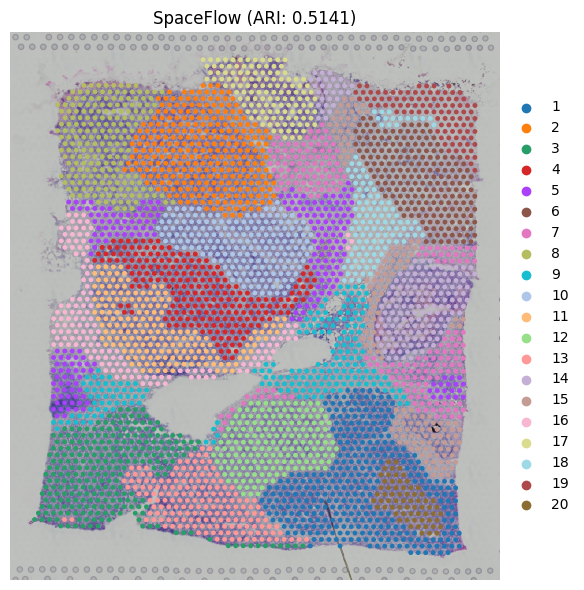

In [55]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(adata, color='pred', ax=axes, show=False)
axes.set_title(f'SpaceFlow (ARI: {metrics["ARI"]:.4f})')
handles, labels = axes.get_legend_handles_labels()
new_labels = [str(int(label) + 1) if label.isdigit() else label for label in labels]
axes.legend(handles, new_labels, loc='center left', frameon=False, bbox_to_anchor=(1, 0.5))
axes.axis('off')
plt.tight_layout()
plt.savefig(dir_output / 'clustering.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
adata.obs['pred'].values

[6, 2, 5, 4, 2, ..., 9, 2, 2, 15, 1]
Length: 3798
Categories (20, int64): [0, 1, 2, 3, ..., 16, 17, 18, 19]

In [57]:
adata.obs['pred_shift'] = (adata.obs['pred'].astype(int) + 1).astype("category")

/home/lytq/.conda/envs/spaceflow_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lytq/.conda/envs/spaceflow_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


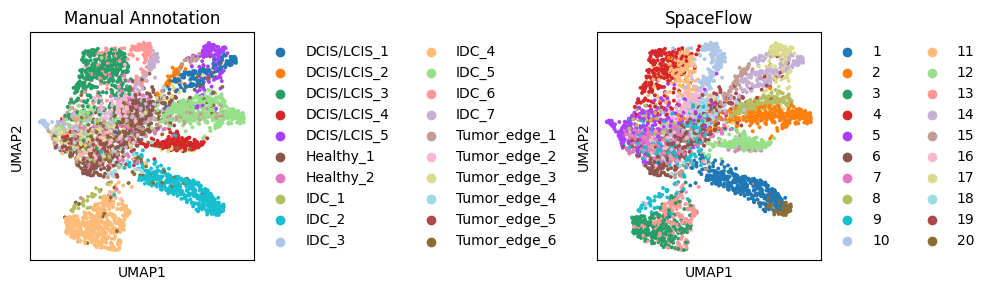

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sc.pl.umap(adata, color='ground_truth', ax=ax[0], show=False)
sc.pl.umap(adata, color='pred_shift', ax=ax[1], show=False)
ax[0].set_title('Manual Annotation')
ax[1].set_title('SpaceFlow')
# handles, labels = ax[1].get_legend_handles_labels()
# new_labels = [str(int(label) + 1) if label.isdigit() else label for label in labels]
# ax[1].legend(handles, new_labels, loc='center left', frameon=False, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(dir_output / 'umap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
adata.obs

,in_tissue,array_row,array_col,layer_guess,pred,ground_truth,pred_shift
AAACAAGTATCTCCCA-1,1,50,102,Tumor_edge_5,6,Tumor_edge_5,7
AAACACCAATAACTGC-1,1,59,19,IDC_4,2,IDC_4,3
AAACAGAGCGACTCCT-1,1,14,94,Healthy_1,5,Healthy_1,6
AAACAGGGTCTATATT-1,1,47,13,IDC_3,4,IDC_3,5
AAACAGTGTTCCTGGG-1,1,73,43,IDC_4,2,IDC_4,3
...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,1,31,77,IDC_7,9,IDC_7,10
TTGTTTCACATCCAGG-1,1,58,42,IDC_4,2,IDC_4,3
TTGTTTCATTAGTCTA-1,1,60,30,IDC_4,2,IDC_4,3
TTGTTTCCATACAACT-1,1,45,27,Tumor_edge_2,15,Tumor_edge_2,16


In [60]:
low_dim_data = pd.DataFrame(adata.obsm["SpaceFlow"], index=adata.obs.index)
low_dim_data.to_csv(dir_output / 'low_dim_data.csv', index=False)

adata.obs.to_csv(dir_output / 'cell_metadata.csv', index=False)
umap_coords = adata.obsm["X_umap"]
spot_ids = adata.obs_names
umap_df = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
umap_df["spot_id"] = spot_ids
umap_df = umap_df[["spot_id", "UMAP1", "UMAP2"]]
umap_df.to_csv(dir_output / "spatial_umap_coords.csv", index=False)